<a href="https://colab.research.google.com/github/dafaisaa/UAS-BengkelKoding-A11.2023.14951/blob/main/UAS_A11_2023_14951.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Atur gaya visualisasi
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

In [3]:
# Menampilkan 5 baris pertama
display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Menampilkan informasi dataset (tipe data dan jumlah baris)
print("\n--- Informasi Dataset ---")
df.info()


--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

In [5]:
# Menampilkan statistik deskriptif
display(df.describe())

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [6]:
# Menghitung persentase missing value per kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("\n--- Persentase Missing Value ---")
print(missing_data)


--- Persentase Missing Value ---
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000
dtype: float64


/tmp/ipykernel_6822/70441659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')


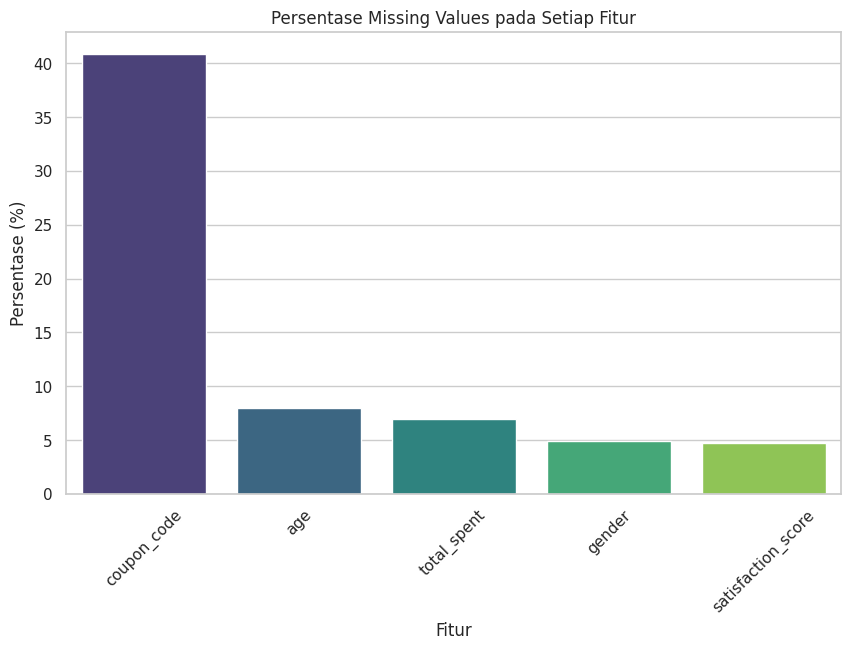

In [7]:
# Membuat diagram batang untuk missing value (jika ada)
if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
    plt.title('Persentase Missing Values pada Setiap Fitur')
    plt.ylabel('Persentase (%)')
    plt.xlabel('Fitur')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Tidak ada missing value pada dataset ini.")

/tmp/ipykernel_6822/251302728.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette='Set2')


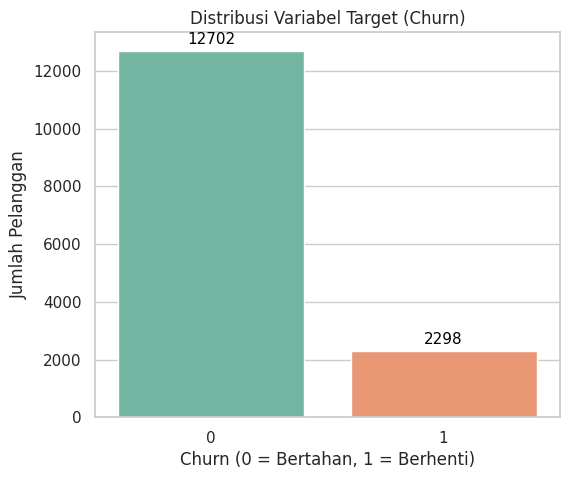

In [8]:
# Menggunakan 'churn' dengan huruf kecil sesuai nama kolom di dataset
target_col = 'churn'

plt.figure(figsize=(6, 5))
ax = sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn (0 = Bertahan, 1 = Berhenti)')
plt.ylabel('Jumlah Pelanggan')

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

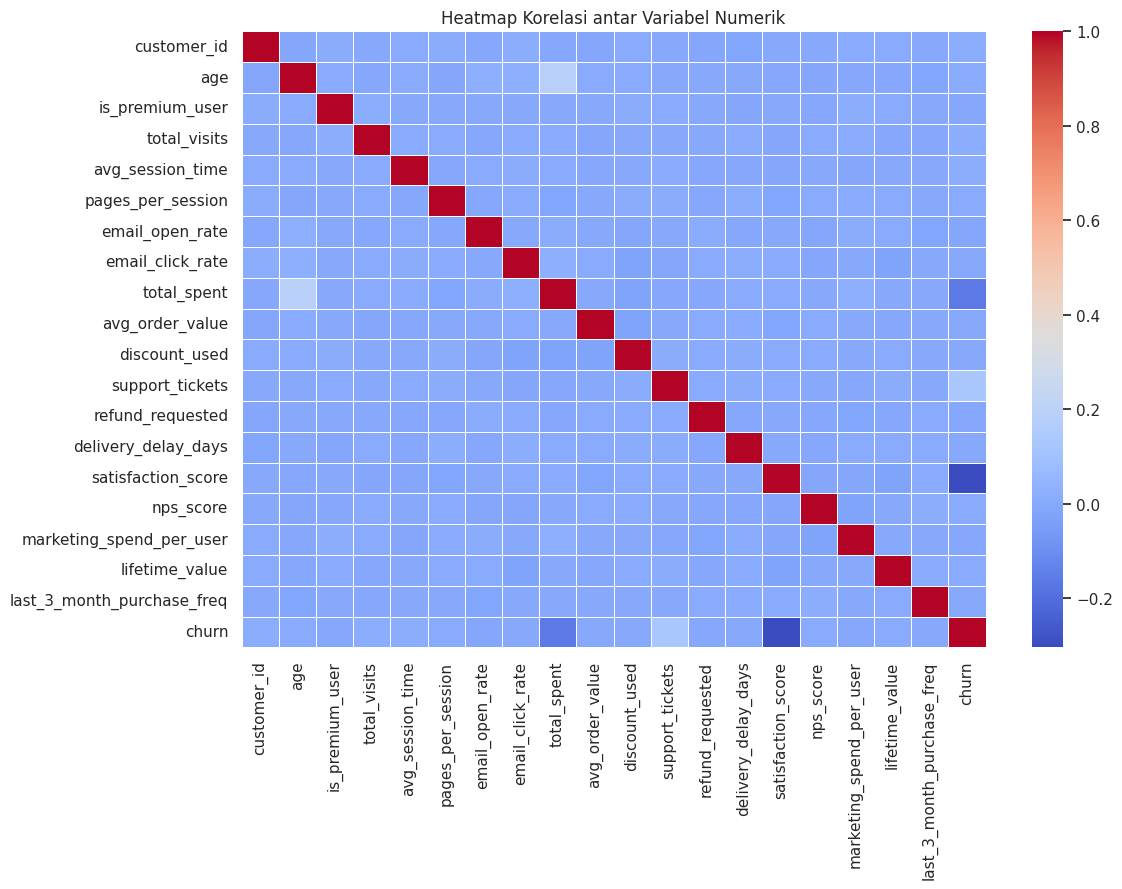

In [9]:
# Memilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
# Hitung korelasi
corr_matrix = numeric_df.corr()
# Buat heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi antar Variabel Numerik')
plt.show()

In [10]:
# PENYESUAIAN DARURAT (Agar model tidak error saat membaca data teks dan NaN)
# 1. Hapus baris yang mengandung missing values
df_clean = df.dropna()
# 2. Ubah kolom teks/kategori menjadi angka (One-Hot Encoding otomatis)
# Ini dilakukan karena KNN, SVM, dan Logistic Regression tidak bisa membaca teks.
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Menetapkan variabel target (y) dan prediktor (X)
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [11]:
# --- TUGAS 2: Train-Test Split ---
# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# --- TUGAS 3: Memilih 3 Kategori Model ---
# 1. Model Konvensional: KNN
model_knn = KNeighborsClassifier()

# 2. Model Ensemble Bagging: Random Forest
model_rf = RandomForestClassifier(random_state=42)

# 3. Model Gabungan (Voting Classifier): Logistic Regression, SVM, KNN
model_lr = LogisticRegression(max_iter=2000, random_state=42)
model_svm = SVC(random_state=42)

model_voting = VotingClassifier(
    estimators=[('lr', model_lr), ('svm', model_svm), ('knn', model_knn)],
    voting='hard'
)

# Kumpulkan model dalam satu dictionary agar mudah dilooping
models = {
    'Konvensional (KNN)': model_knn,
    'Ensemble Bagging (Random Forest)': model_rf,
    'Gabungan (Voting Classifier)': model_voting
}


Melatih dan Mengevaluasi Model: Konvensional (KNN)
Accuracy  : 0.8370
Precision : 0.4590
Recall    : 0.1279
F1-Score  : 0.2000


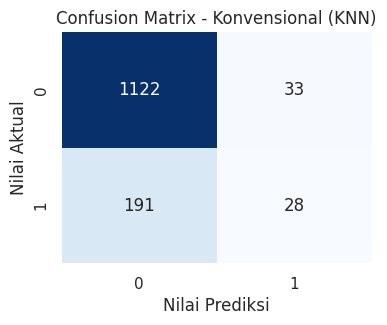


Melatih dan Mengevaluasi Model: Ensemble Bagging (Random Forest)
Accuracy  : 0.8428
Precision : 0.5366
Recall    : 0.1005
F1-Score  : 0.1692


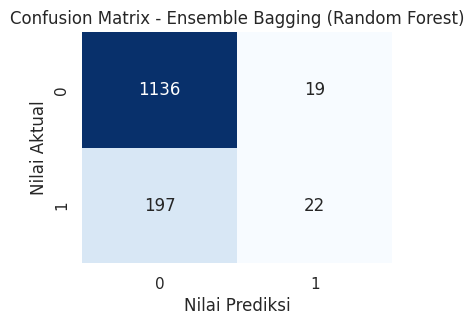


Melatih dan Mengevaluasi Model: Gabungan (Voting Classifier)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.8421
Precision : 0.6250
Recall    : 0.0228
F1-Score  : 0.0441


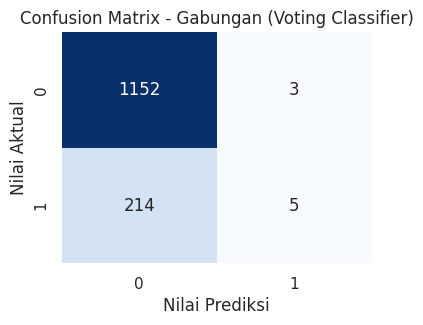

In [16]:
# --- TUGAS 4 & 5: Melatih (Tanpa Preprocessing/Tuning) & Mengevaluasi Model ---
for name, model in models.items():
    print(f"\n=======================================================")
    print(f"Melatih dan Mengevaluasi Model: {name}")
    print(f"=======================================================")

    # Proses Training
    model.fit(X_train, y_train)

    # Proses Prediksi
    y_pred = model.predict(X_test)

    # Menampilkan Metrik Evaluasi
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

    # Menampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Nilai Aktual')
    plt.xlabel('Nilai Prediksi')
    plt.show()